# 0. Install necessary packages.
## RESTART AFTER THIS CELL IS RUN.

In [ ]:
!pip install tensorflow
!pip install -U "jax[tpu]"
!pip install -U flax
!pip install -U jaxlib

### Be sure to restart the noteboook after the above cell is run

# 1. Set up Google Colab and Link Google Drive

In [1]:
# Set up Google Colab and link Google Drive
import os
import signal
from google.colab import drive

# 1. Mount the full drive
drive.mount('/content/drive')

# 2. Change directory to your project folder
print('Current working directory:')
os.chdir('/content/drive/My Drive/demo_drive_folder/')
os.makedirs('saved_models', exist_ok = True)

# 3. git clone bonsai
!git clone https://github.com/jax-ml/bonsai.git

# Verify it worked
print(os.getcwd())
print(os.listdir())

# Load jax
import jax.tools.colab_tpu
import jax
from jax.extend import backend
print("JAX platform:", backend.get_backend().platform)
print("JAX devices:", jax.devices())

Mounted at /content/drive
Current working directory:
Cloning into 'bonsai'...
remote: Enumerating objects: 2172, done.
remote: Counting objects: 100% (828/828), done.
remote: Compressing objects: 100% (417/417), done.
remote: Total 2172 (delta 621), reused 412 (delta 411), pack-reused 1344 (from 2)
Receiving objects: 100% (2172/2172), 8.71 MiB | 30.43 MiB/s, done.
Resolving deltas: 100% (1246/1246), done.
/content/drive/My Drive/demo_drive_folder
['saved_models', 'bonsai']


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:93: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


JAX platform: tpu
JAX devices: [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0)]


# 2. Load the MNIST dataset

In [2]:
import tensorflow_datasets as tfds  # TFDS to download MNIST.
import tensorflow as tf  # TensorFlow / `tf.data` operations.

tf.random.set_seed(0)  # Set the random seed for reproducibility.

train_steps = 1200
eval_every = 200
batch_size = 32

train_ds: tf.data.Dataset = tfds.load('mnist', split='train')
test_ds: tf.data.Dataset = tfds.load('mnist', split='test')

train_ds = train_ds.map(
  lambda sample: {
    'image': tf.cast(sample['image'], tf.float32) / 255,
    'label': sample['label'],
  }
)  # normalize train set
test_ds = test_ds.map(
  lambda sample: {
    'image': tf.cast(sample['image'], tf.float32) / 255,
    'label': sample['label'],
  }
)  # Normalize the test set.

# Create a shuffled dataset by allocating a buffer size of 1024 to randomly draw elements from.
train_ds = train_ds.repeat().shuffle(1024)
# Group into batches of `batch_size` and skip incomplete batches, prefetch the next sample to improve latency.
train_ds = train_ds.batch(batch_size, drop_remainder=True).take(train_steps).prefetch(1)
# Group into batches of `batch_size` and skip incomplete batches, prefetch the next sample to improve latency.
test_ds = test_ds.batch(batch_size, drop_remainder=True).prefetch(1)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.U3V87B_3.0.1/mnist-train.tfrecord*...:   0%|          | 0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/mnist/incomplete.U3V87B_3.0.1/mnist-test.tfrecord*...:   0%|          | 0/…

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


# 3. Define the model with Flax NNX

In [3]:
from flax import nnx  # The Flax NNX API.
from functools import partial
from typing import Optional

class CNN(nnx.Module):
  """A simple CNN model."""

  def __init__(self, *, rngs: nnx.Rngs):
    self.conv1 = nnx.Conv(1, 32, kernel_size=(3, 3), rngs=rngs)
    self.batch_norm1 = nnx.BatchNorm(32, rngs=rngs)
    self.dropout1 = nnx.Dropout(rate=0.025)
    self.conv2 = nnx.Conv(32, 64, kernel_size=(3, 3), rngs=rngs)
    self.batch_norm2 = nnx.BatchNorm(64, rngs=rngs)
    self.avg_pool = partial(nnx.avg_pool, window_shape=(2, 2), strides=(2, 2))
    self.linear1 = nnx.Linear(3136, 256, rngs=rngs)
    self.dropout2 = nnx.Dropout(rate=0.025)
    self.linear2 = nnx.Linear(256, 10, rngs=rngs)

  def __call__(self, x, rngs: Optional[nnx.Rngs] = None):
    x = self.avg_pool(nnx.relu(self.batch_norm1(self.dropout1(self.conv1(x), rngs=rngs))))
    x = self.avg_pool(nnx.relu(self.batch_norm2(self.conv2(x))))
    x = x.reshape(x.shape[0], -1)  # flatten
    x = nnx.relu(self.dropout2(self.linear1(x), rngs=rngs))
    x = self.linear2(x)
    return x

# Instantiate the model.
model = CNN(rngs=nnx.Rngs(0))
# Visualize it.
nnx.display(model)

# Run the model

In [4]:
import jax.numpy as jnp  # JAX NumPy

y = model(jnp.ones((1, 28, 28, 1)), nnx.Rngs(0))
y

Array([[ 0.11486965,  0.45578003, -0.641175  , -0.12032188, -0.22813551,
         0.1358296 ,  1.013555  , -0.03534585,  0.6127418 , -0.06210104]],      dtype=float32)

# 4. Create the optimizer and define some metrics

In [5]:
import optax

learning_rate = 0.005
momentum = 0.9

optimizer = nnx.Optimizer(
  model, optax.adamw(learning_rate, momentum), wrt=nnx.Param
)
metrics = nnx.MultiMetric(
  accuracy=nnx.metrics.Accuracy(),
  loss=nnx.metrics.Average('loss'),
)

nnx.display(optimizer)

# 5. Define training step functions

In [6]:
def loss_fn(model: CNN, rngs: nnx.Rngs, batch):
  logits = model(batch['image'], rngs)
  loss = optax.softmax_cross_entropy_with_integer_labels(
    logits=logits, labels=batch['label']
  ).mean()
  return loss, logits

@nnx.jit
def train_step(model: CNN, optimizer: nnx.Optimizer, metrics: nnx.MultiMetric, rngs: nnx.Rngs, batch):
  """Train for a single step."""
  grad_fn = nnx.value_and_grad(loss_fn, has_aux=True)
  (loss, logits), grads = grad_fn(model, rngs, batch)
  metrics.update(loss=loss, logits=logits, labels=batch['label'])  # In-place updates.
  optimizer.update(model, grads)  # In-place updates.

@nnx.jit
def eval_step(model: CNN, metrics: nnx.MultiMetric, rngs: nnx.Rngs, batch):
  loss, logits = loss_fn(model, rngs, batch)
  metrics.update(loss=loss, logits=logits, labels=batch['label'])  # In-place updates.

# 6. Train and evaluate the model

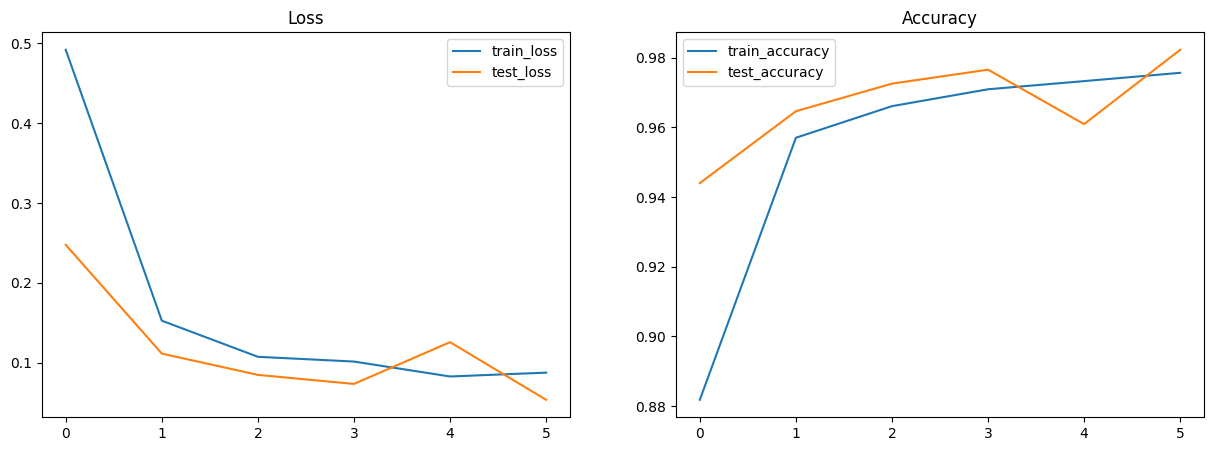

In [7]:
from IPython.display import clear_output
import matplotlib.pyplot as plt

metrics_history = {
  'train_loss': [],
  'train_accuracy': [],
  'test_loss': [],
  'test_accuracy': [],
}

rngs = nnx.Rngs(0)

for step, batch in enumerate(train_ds.as_numpy_iterator()):
  # Run the optimization for one step and make a stateful update to the following:
  # - The train state's model parameters
  # - The optimizer state
  # - The training loss and accuracy batch metrics
  model.train() # Switch to train mode
  train_step(model, optimizer, metrics, rngs, batch)

  if step > 0 and (step % eval_every == 0 or step == train_steps - 1):  # One training epoch has passed.
    # Log the training metrics.
    for metric, value in metrics.compute().items():  # Compute the metrics.
      metrics_history[f'train_{metric}'].append(value)  # Record the metrics.
    metrics.reset()  # Reset the metrics for the test set.

    # Compute the metrics on the test set after each training epoch.
    model.eval() # Switch to eval mode
    for test_batch in test_ds.as_numpy_iterator():
      eval_step(model, metrics, rngs, test_batch)

    # Log the test metrics.
    for metric, value in metrics.compute().items():
      metrics_history[f'test_{metric}'].append(value)
    metrics.reset()  # Reset the metrics for the next training epoch.

    clear_output(wait=True)
    # Plot loss and accuracy in subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.set_title('Loss')
    ax2.set_title('Accuracy')
    for dataset in ('train', 'test'):
      ax1.plot(metrics_history[f'{dataset}_loss'], label=f'{dataset}_loss')
      ax2.plot(metrics_history[f'{dataset}_accuracy'], label=f'{dataset}_accuracy')
    ax1.legend()
    ax2.legend()
    plt.show()

# 7. Perform inference on the test set

In [8]:
model.eval() # Switch to evaluation mode.

@nnx.jit
def pred_step(model: CNN, batch):
  logits = model(batch['image'], None)
  return logits.argmax(axis=1)

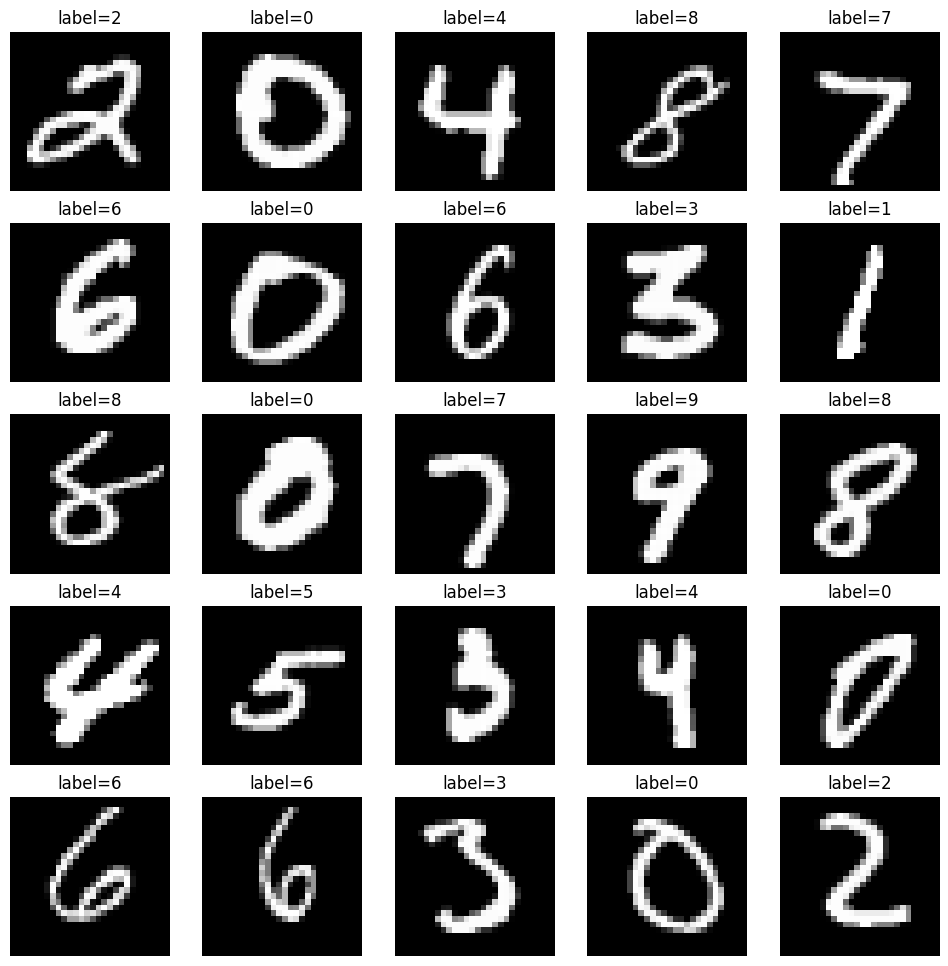

In [9]:
test_batch = test_ds.as_numpy_iterator().next()
pred = pred_step(model, test_batch)

fig, axs = plt.subplots(5, 5, figsize=(12, 12))
for i, ax in enumerate(axs.flatten()):
  ax.imshow(test_batch['image'][i, ..., 0], cmap='gray')
  ax.set_title(f'label={pred[i]}')
  ax.axis('off')

# 8. Export the model

In [10]:
from orbax.export import JaxModule, ExportManager, ServingConfig

In [11]:
def exported_predict(model, y):
    return model(y, None)

jax_module = JaxModule(model, exported_predict)

In [12]:
sig = [tf.TensorSpec(shape=(1, 28, 28, 1), dtype=tf.float32)]

In [13]:
export_mgr = ExportManager(jax_module, [
    ServingConfig('mnist_server', input_signature=sig)
])

output_dir='saved_models/demo_model'
export_mgr.save(output_dir)

In [14]:
!ls saved_models/demo_model

assets	fingerprint.pb	saved_model.pb	variables


# 9. Unmount Google Drive

In [15]:
drive.flush_and_unmount()
print('Safe to unmount from Google Drive.')

Safe to unmount from Google Drive.


# 10. Release TPU

In [ ]:
# This forces the kernel to exit, which triggers 
# the TPU driver to release the hardware lock immediately.
os.kill(os.getpid(), signal.SIGTERM)

: 

: 

: 